# 채널 정체 확률 모델
## 전체 위험도 프레임워크에서의 위치

```
최종 위험도 (ABCDF)
├── 평판 위험도 33%   댓글 감성 + 민감 키워드
├── 트래픽 위험도 33% 이탈 확률 + [채널 정체 확률 ← 현재] + 조회수 변동성 + 업로드 주기 불확실성
└── 팬덤 위험도 33%   활성 시청자 비율 + 시청 유지 안정성
```

## 채널 정체 정의
> 최근 영상 50개(최신 1개 제외)의 조회수가 **수평 또는 하락 추세**인 채널

최신 영상 1개는 조회수가 충분히 쌓이지 않았다고 가정하여 **분석에서 제외**합니다.

## 출력
각 채널에 대해 **정체 확률 0 ~ 1** 을 출력합니다.


## 0. 라이브러리

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from scipy.stats             import linregress
from sklearn.impute           import SimpleImputer
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.model_selection  import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.linear_model     import LogisticRegression
from sklearn.ensemble         import RandomForestClassifier
from sklearn.calibration      import CalibratedClassifierCV, calibration_curve
from sklearn.metrics          import (roc_auc_score, brier_score_loss,
                                      roc_curve, classification_report,
                                      ConfusionMatrixDisplay, confusion_matrix)
from xgboost import XGBClassifier

RANDOM_STATE = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print("라이브러리 로드 완료")


라이브러리 로드 완료


In [1]:
# 폰트
import matplotlib.pyplot as plt

# macOS에서 가장 많이 사용하는 설정
plt.rcParams["font.family"] = "AppleGothic" # 혹은 "Apple SD Gothic Neo"
plt.rcParams["axes.unicode_minus"] = False

print("macOS 한글 폰트 설정 완료")

macOS 한글 폰트 설정 완료


## 1. 데이터 로드

In [4]:
long = pd.read_csv("filtered_dataset_long.csv")
long["published_at"] = pd.to_datetime(long["published_at"], utc=True, errors="coerce")
long["is_shorts"]    = long["is_shorts"].astype(str).str.lower() == "true"
long = long.sort_values(["channel_id", "published_at"]).reset_index(drop=True)

NOW = pd.Timestamp.now(tz="UTC")
print(f"long shape : {long.shape}")
print(f"채널 수    : {long['channel_id'].nunique()}")


long shape : (166449, 18)
채널 수    : 3336


## 2. 피처 엔지니어링

채널당 영상을 시간순 정렬 후 **최신 1개 제외**, 나머지로 아래 피처를 계산합니다.

| 피처 | 설명 | 정체 신호 |
|---|---|---|
| `log_slope` | 로그 조회수의 선형 기울기 | 음수일수록 하락 추세 |
| `r_squared` | 기울기의 결정계수 | 높을수록 추세가 뚜렷함 |
| `change_rate_half` | 후반부 평균 / 전반부 평균 − 1 | 음수면 후반부 성과 하락 |
| `recent10_vs_all` | 최근 10개 평균 / 전체 평균 − 1 | 음수면 최근 성과 하락 |
| `view_cv` | 조회수 변동계수(std/mean) | 낮으면 변화 없이 고착 |
| `pct_below_median` | 전체 중앙값 미만 영상 비율 | 높을수록 전반적 부진 |
| `momentum_3` | 최근 3개 평균 / 직전 3개 평균 − 1 | 음수면 최근 모멘텀 약화 |
| `trend_accel` | 전체 slope - 후반부만의 slope | 음수면 최근 들어 더 가파르게 하락 |


In [5]:
def extract_stagnation_features(group):
    g = group.sort_values("published_at")

    # ── 최신 1개 제외 ─────────────────────────────────────────────────────
    g = g.iloc[:-1]
    if len(g) < 5:
        return None

    views     = g["view_count"].fillna(0).tolist()
    log_views = np.log1p(views)
    x         = np.arange(len(log_views))
    n         = len(views)
    half      = n // 2

    # ── log_slope, r_squared ──────────────────────────────────────────────
    slope, _, r, _, _ = linregress(x, log_views)
    r_sq = r ** 2

    # ── change_rate_half: 후반부 vs 전반부 ──────────────────────────────
    first_avg  = np.mean(views[:half]) + 1e-9
    second_avg = np.mean(views[half:])
    change_rate_half = (second_avg - first_avg) / first_avg

    # ── recent10_vs_all: 최근 10개 vs 전체 ──────────────────────────────
    if n >= 12:
        recent10_avg = np.mean(views[-10:])
        older_avg    = np.mean(views[:-10]) + 1e-9
        recent10_vs_all = (recent10_avg - older_avg) / older_avg
    else:
        recent10_vs_all = np.nan

    # ── view_cv: 변동계수 ─────────────────────────────────────────────────
    view_cv = np.std(views) / (np.mean(views) + 1e-9)

    # ── pct_below_median ─────────────────────────────────────────────────
    median_v       = np.median(views)
    pct_below_med  = np.mean([1 if v < median_v else 0 for v in views])

    # ── momentum_3: 최근 3개 vs 직전 3개 ────────────────────────────────
    if n >= 6:
        momentum_3 = (np.mean(views[-3:]) - np.mean(views[-6:-3])) / (np.mean(views[-6:-3]) + 1e-9)
    else:
        momentum_3 = np.nan

    # ── trend_accel: 전체 slope - 후반 slope (가속 여부) ─────────────
    x_second   = np.arange(len(views[half:]))
    slope_2nd, *_ = linregress(x_second, np.log1p(views[half:]))
    trend_accel = slope - slope_2nd   # 음수면 최근 들어 더 가파르게 하락

    return pd.Series({
        "log_slope"       : round(slope, 5),
        "r_squared"       : round(r_sq, 4),
        "change_rate_half": round(change_rate_half, 4),
        "recent10_vs_all" : round(recent10_vs_all, 4) if not np.isnan(recent10_vs_all) else np.nan,
        "view_cv"         : round(view_cv, 4),
        "pct_below_median": round(pct_below_med, 4),
        "momentum_3"      : round(momentum_3, 4) if not np.isnan(momentum_3) else np.nan,
        "trend_accel"     : round(trend_accel, 5),
    })

feat_df = long.groupby("channel_id").apply(
    extract_stagnation_features, include_groups=False
).dropna(how="all").reset_index()

# channel_title 붙이기
titles = long.groupby("channel_id")["channel_title"].first().reset_index()
feat_df = feat_df.merge(titles, on="channel_id")

print(f"피처 테이블 shape: {feat_df.shape}")
feat_df.describe().round(3)


피처 테이블 shape: (3333, 10)


,log_slope,r_squared,change_rate_half,recent10_vs_all,view_cv,pct_below_median,momentum_3,trend_accel
count,3333.000,3333.000,3333.000,3333.000,3333.000,3333.000,3333.000,3333.000
mean,-0.011,0.104,0.350,-0.103,1.525,0.490,1.718,0.007
std,0.025,0.131,11.616,1.300,1.004,0.001,41.836,0.044
min,-0.157,0.000,-1.000,-1.000,0.120,0.467,-1.000,-0.209
25%,-0.023,0.012,-0.483,-0.607,0.823,0.490,-0.474,-0.015
50%,-0.010,0.054,-0.213,-0.338,1.246,0.490,-0.123,0.006
75%,0.002,0.144,0.163,-0.013,1.938,0.490,0.479,0.030
max,0.146,0.881,658.325,28.253,6.917,0.500,2252.628,0.349


## 3. 정체 라벨 생성

두 조건을 **동시에** 만족하는 채널을 정체(1)로 정의합니다.

| 조건 | 기준 | 의미 |
|---|---|---|
| `log_slope < -0.005` | 전체 조회수 추세가 하락 | 시간이 지날수록 조회수가 떨어지는 추세 |
| `change_rate_half < -0.1` | 후반부 평균이 전반부보다 10% 이상 낮음 | 최근 영상들이 과거 영상보다 실제로 성과가 낮음 |

두 조건 모두 충족해야 정체로 보는 이유: slope만 보면 오래된 인기 영상 때문에 왜곡될 수 있고,  
change_rate만 보면 일시적 변동에 민감합니다. **두 신호가 일치할 때만 정체로 판정**합니다.


=== 라벨 분포 ===
is_stagnant
1    1712
0    1621
Name: count, dtype: int64

정체 채널 비율: 51.4%


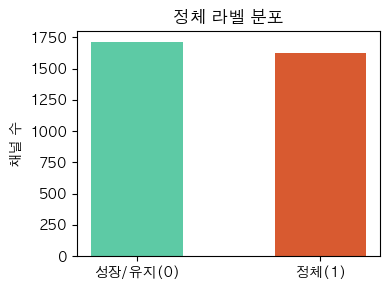

In [6]:
feat_df["is_stagnant"] = (
    (feat_df["log_slope"]        < -0.005) &
    (feat_df["change_rate_half"] < -0.1)
).astype(int)

print("=== 라벨 분포 ===")
vc = feat_df["is_stagnant"].value_counts()
print(vc)
print(f"\n정체 채널 비율: {feat_df['is_stagnant'].mean():.1%}")

fig, ax = plt.subplots(figsize=(4, 3))
ax.bar(["성장/유지(0)", "정체(1)"], vc.values,
       color=["#5DCAA5", "#D85A30"], edgecolor="none", width=0.5)
ax.set_ylabel("채널 수")
ax.set_title("정체 라벨 분포")
plt.tight_layout()
plt.show()


## 4. 피처-라벨 상관관계

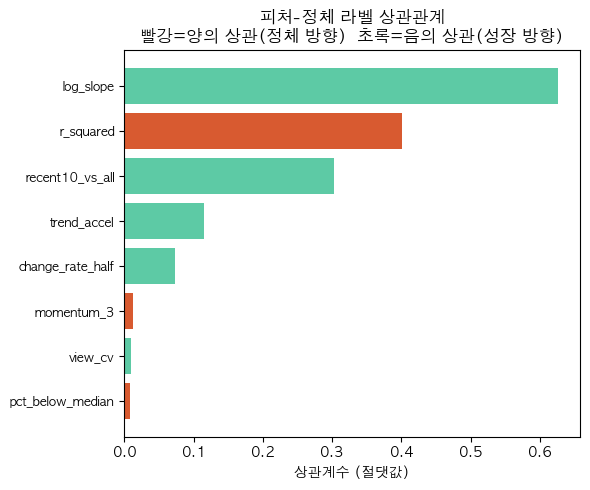

In [7]:
FEATURE_COLS = [
    "log_slope", "r_squared", "change_rate_half",
    "recent10_vs_all", "view_cv", "pct_below_median",
    "momentum_3", "trend_accel",
]

corr = feat_df[FEATURE_COLS + ["is_stagnant"]].corr()["is_stagnant"].drop("is_stagnant")
corr_abs = corr.abs().sort_values(ascending=True)
colors = ["#D85A30" if corr[f] > 0 else "#5DCAA5" for f in corr_abs.index]

fig, ax = plt.subplots(figsize=(6, 5))
ax.barh(corr_abs.index, corr_abs.values, color=colors, edgecolor="none")
ax.set_xlabel("상관계수 (절댓값)")
ax.set_title("피처-정체 라벨 상관관계\n빨강=양의 상관(정체 방향)  초록=음의 상관(성장 방향)")
ax.tick_params(axis="y", labelsize=9)
plt.tight_layout()
plt.show()


## 5. 정체 / 성장 채널 조회수 추이 비교 (샘플)

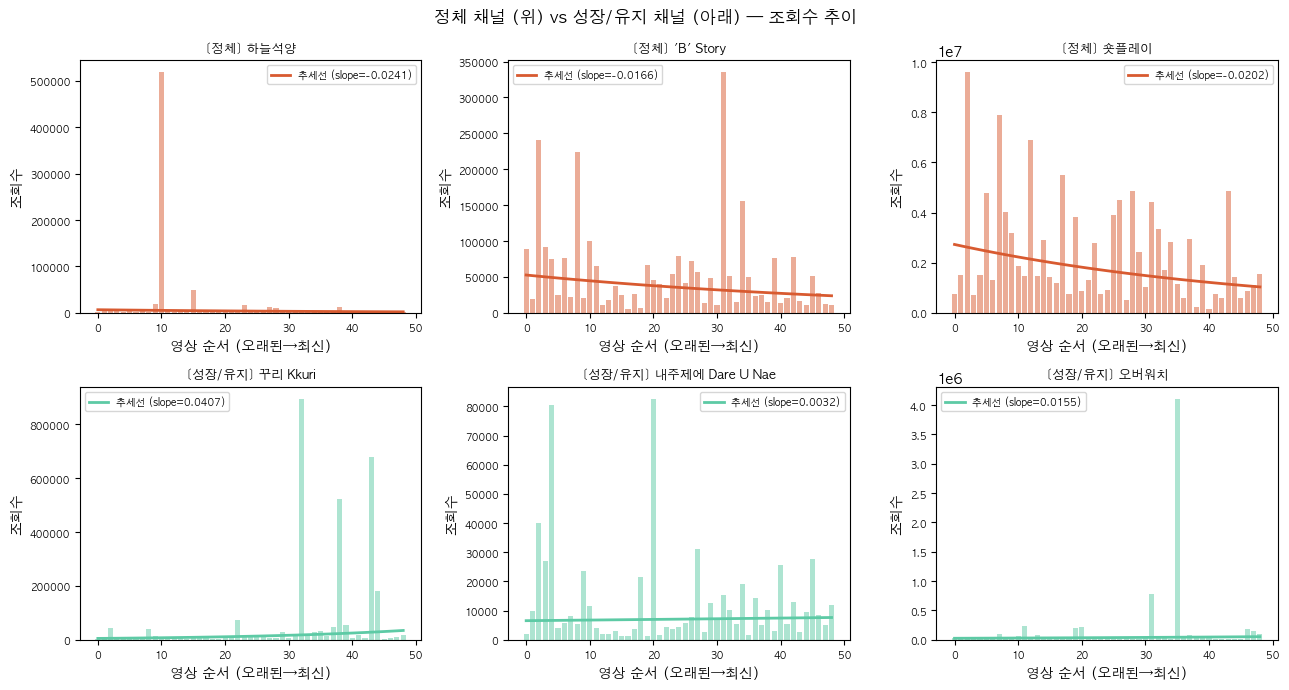

In [8]:
stagnant_ids = feat_df[feat_df["is_stagnant"] == 1]["channel_id"].tolist()[:3]
growth_ids   = feat_df[feat_df["is_stagnant"] == 0]["channel_id"].tolist()[:3]

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
fig.suptitle("정체 채널 (위) vs 성장/유지 채널 (아래) — 조회수 추이", fontsize=12)

for i, (cid, ax) in enumerate(zip(stagnant_ids + growth_ids, axes.flatten())):
    g = long[long["channel_id"] == cid].sort_values("published_at").iloc[:-1]
    views = g["view_count"].fillna(0).tolist()
    x = np.arange(len(views))
    slope, intercept, *_ = linregress(x, np.log1p(views))
    trend = np.expm1(slope * x + intercept)

    color = "#D85A30" if i < 3 else "#5DCAA5"
    label = "정체" if i < 3 else "성장/유지"
    title = g["channel_title"].iloc[0][:15]

    ax.bar(x, views, color=color, alpha=0.5, edgecolor="none", width=0.8)
    ax.plot(x, trend, color=color, lw=2, label=f"추세선 (slope={slope:.4f})")
    ax.set_title(f"[{label}] {title}", fontsize=9)
    ax.set_xlabel("영상 순서 (오래된→최신)")
    ax.set_ylabel("조회수")
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()


## 6. 모델 정의

3개 모델의 **앙상블 평균**을 최종 정체 확률로 사용합니다.  
XGBoost는 `CalibratedClassifierCV`로 확률 보정합니다.


In [9]:
X = feat_df[FEATURE_COLS].copy()
y = feat_df["is_stagnant"].copy()

pos_weight = (y == 0).sum() / (y == 1).sum()

xgb_base = XGBClassifier(
    n_estimators     = 200,
    max_depth        = 3,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    scale_pos_weight = pos_weight,
    eval_metric      = "logloss",
    random_state     = RANDOM_STATE,
    verbosity        = 0,
)

models = {
    "Logistic Regression": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  StandardScaler()),
        ("clf", LogisticRegression(
            class_weight="balanced", C=0.1,
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
    "Random Forest": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=200, max_depth=5,
            class_weight="balanced", random_state=RANDOM_STATE,
        )),
    ]),
    "XGBoost (calibrated)": Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("clf", CalibratedClassifierCV(xgb_base, cv=3, method="isotonic")),
    ]),
}

print(f"피처 수 : {len(FEATURE_COLS)}")
print(f"샘플 수 : {len(X)}")
print(f"정체 비율: {y.mean():.1%}")


피처 수 : 8
샘플 수 : 3333
정체 비율: 51.4%


## 7. 교차검증

In [10]:
results = {}

for name, model in models.items():
    cv_res  = cross_validate(model, X, y, cv=CV,
                             scoring=["roc_auc","f1","recall","precision"])
    y_prob  = cross_val_predict(model, X, y, cv=CV, method="predict_proba")[:, 1]
    brier   = brier_score_loss(y, y_prob)

    results[name] = {
        "AUC-ROC"  : cv_res["test_roc_auc"].mean(),
        "F1"       : cv_res["test_f1"].mean(),
        "Recall"   : cv_res["test_recall"].mean(),
        "Precision": cv_res["test_precision"].mean(),
        "Brier↓"   : round(brier, 4),
    }
    print(f"[{name}]  AUC={results[name]['AUC-ROC']:.3f}  F1={results[name]['F1']:.3f}  Brier={brier:.3f}")

res_df = pd.DataFrame(results).T.round(3)
print()
res_df


[Logistic Regression]  AUC=0.963  F1=0.907  Brier=0.076
[Random Forest]  AUC=1.000  F1=0.999  Brier=0.007
[XGBoost (calibrated)]  AUC=1.000  F1=0.999  Brier=0.001



,AUC-ROC,F1,Recall,Precision,Brier↓
Logistic Regression,0.963,0.907,0.894,0.921,0.076
Random Forest,1.000,0.999,0.999,1.000,0.007
XGBoost (calibrated),1.000,0.999,0.999,0.999,0.001


## 8. ROC 커브 & Calibration Curve

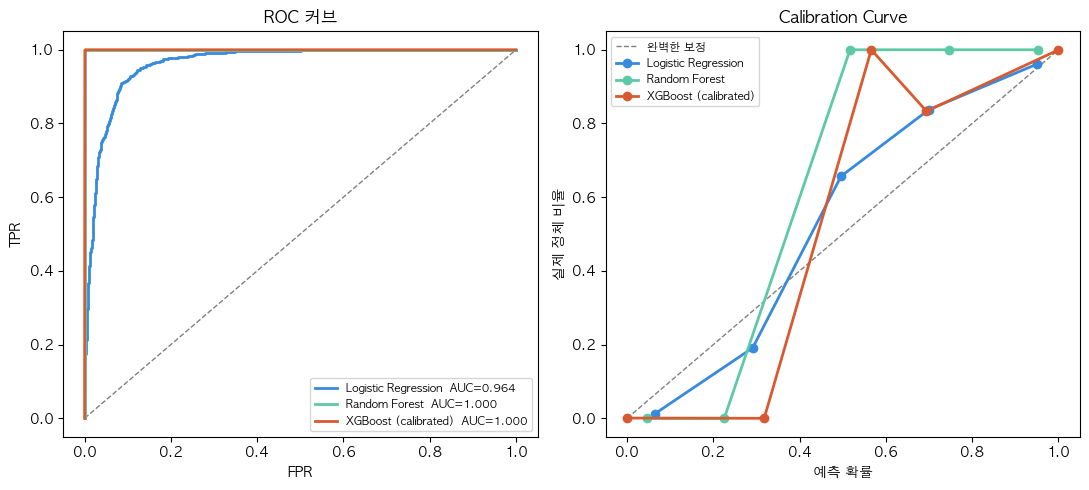

In [11]:
pal = {"Logistic Regression":"#378ADD",
       "Random Forest":"#5DCAA5",
       "XGBoost (calibrated)":"#D85A30"}

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# ROC
axes[0].plot([0,1],[0,1],"--", color="gray", lw=1)
for name, model in models.items():
    y_prob = cross_val_predict(model, X, y, cv=CV, method="predict_proba")[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    auc = roc_auc_score(y, y_prob)
    axes[0].plot(fpr, tpr, lw=2, label=f"{name}  AUC={auc:.3f}", color=pal[name])
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC 커브"); axes[0].legend(fontsize=8)

# Calibration
axes[1].plot([0,1],[0,1],"--", color="gray", lw=1, label="완벽한 보정")
for name, model in models.items():
    y_prob = cross_val_predict(model, X, y, cv=CV, method="predict_proba")[:, 1]
    frac, mean_p = calibration_curve(y, y_prob, n_bins=5, strategy="uniform")
    axes[1].plot(mean_p, frac, "o-", lw=2, label=name, color=pal[name])
axes[1].set_xlabel("예측 확률"); axes[1].set_ylabel("실제 정체 비율")
axes[1].set_title("Calibration Curve"); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


## 9. 채널별 정체 확률 출력

전체 데이터 재학습 후 앙상블 평균을 `stagnation_prob`으로 출력합니다.


In [12]:
imp = SimpleImputer(strategy="median")
X_imp = pd.DataFrame(imp.fit_transform(X), columns=FEATURE_COLS)

prob_dict = {}
for name, model in models.items():
    model.fit(X_imp, y)
    prob_dict[name] = model.predict_proba(X_imp)[:, 1]

probs = pd.DataFrame(prob_dict)
probs["stagnation_prob"] = probs.mean(axis=1)
probs["channel_id"]      = feat_df["channel_id"].values
probs["title"]           = feat_df["channel_title"].values
probs["is_stagnant"]     = y.values

output = probs[[
    "channel_id", "title", "is_stagnant",
    "Logistic Regression", "Random Forest",
    "XGBoost (calibrated)", "stagnation_prob"
]].sort_values("stagnation_prob", ascending=False).reset_index(drop=True)

output.columns = [
    "channel_id", "title", "actual_label",
    "prob_lr", "prob_rf", "prob_xgb", "stagnation_prob"
]
output = output.round(3)
print(f"정체 확률 계산 완료: {len(output)}개 채널")
output


정체 확률 계산 완료: 3333개 채널


,channel_id,title,actual_label,prob_lr,prob_rf,prob_xgb,stagnation_prob
0,UCklDsqQMGPYIMpIhQ5Jz6jA,모양몬 로블록스,1,1.0,0.988,1.0,0.996
1,UC9gxOp_-R78phMHmv2bW_sg,원지의하루,1,1.0,0.988,1.0,0.996
2,UCzjEp3u8RMkOJwpc3RzxmWg,콩콩이다,1,1.0,0.988,1.0,0.996
3,UCyyWcEhqfaqJQ56XdA44RYQ,챔보,1,1.0,0.988,1.0,0.996
4,UCZyYOvUGGiDFkEB8G9StWBA,집에서안나와 - with ANNA,1,1.0,0.988,1.0,0.996
...,...,...,...,...,...,...,...
3328,UCdY9ynhPfqPOTpYbhZoUjSw,8초 TV,0,0.0,0.002,0.0,0.001
3329,UCrlp00QA7rEnBgKH9CW6BTQ,진짜사랑,0,0.0,0.002,0.0,0.001
3330,UC_FN_E93oCL8kY_hwPJcarw,풋볼아이 FootballEye,0,0.0,0.002,0.0,0.001
3331,UCRvGVXlK9h9vLWpbVOzm_4Q,PRISTIN,0,0.0,0.001,0.0,0.000


## 10. 채널별 정체 확률 시각화

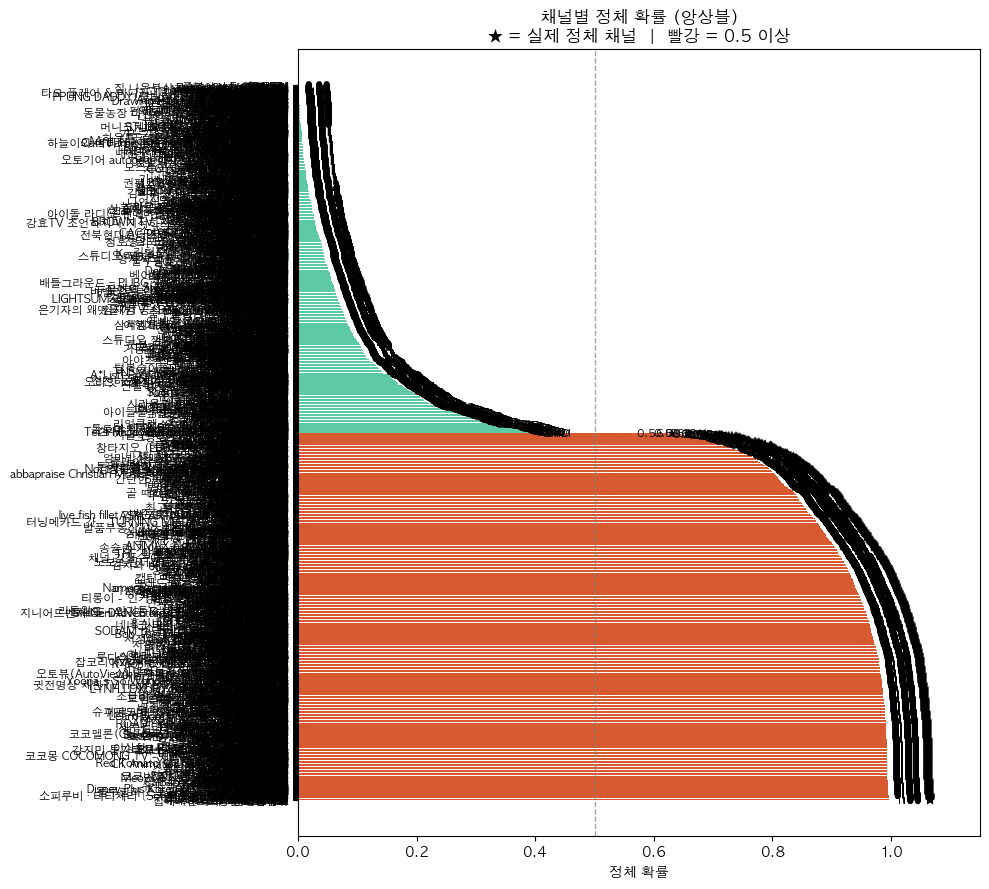

In [15]:
fig, ax = plt.subplots(figsize=(10, 9))
colors_bar = ["#D85A30" if v >= 0.5 else "#5DCAA5" for v in output["stagnation_prob"]]
ax.barh(output["title"], output["stagnation_prob"],
        color=colors_bar, edgecolor="none")

for i, (prob, actual) in enumerate(zip(output["stagnation_prob"], output["actual_label"])):
    marker = " ★" if actual == 1 else ""
    ax.text(prob + 0.01, i, f"{prob:.2f}{marker}", va="center", fontsize=8)

ax.axvline(0.5, color="gray", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("정체 확률")
ax.set_title("채널별 정체 확률 (앙상블)\n★ = 실제 정체 채널  |  빨강 = 0.5 이상")
ax.set_xlim(0, 1.15)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()


## 11. 저장

In [16]:
output.to_csv("stagnation_probability_output.csv", index=False, encoding="utf-8-sig")
print("저장 완료: stagnation_probability_output.csv")
print()
print("=== 정체 확률 상위 10개 채널 ===")
print(output[["title","stagnation_prob","actual_label"]].head(10).to_string(index=False))


저장 완료: stagnation_probability_output.csv

=== 정체 확률 상위 10개 채널 ===
             title  stagnation_prob  actual_label
          모양몬 로블록스            0.996             1
             원지의하루            0.996             1
              콩콩이다            0.996             1
                챔보            0.996             1
집에서안나와 - with ANNA            0.996             1
               깡시안            0.996             1
     하와이골프 [박형준프로]            0.996             1
  bobaepapa - 보배아빠            0.996             1
 Mellowbeat Seeker            0.996             1
         한별Hanbyul            0.996             1
